## Statistical Inference - Analyzing Simulated Particle Physics Data

*Statistical inference: the process of using a limited sample of data to draw conclusions about a larger, unseen population.*

Here we use thousands of "events" to infer the properties of a particle. 

The methods used here are crucial to data analysis.

We will perform a simplified particle physics analysis:
* Generate binned simulated data from real-world parameters for a signal (a "particle") on top of a background
* Fit a model to this data
* Evaluate the "goodness-of-fit" and "p-value" of the model 
* Perform a "pull study" to check if the fit is `unbiased`

All the formulae to do this are provided below.

First, we import the necessary libraries and define the mathematical models for our signal and background. The signal is a Gaussian distribution, and the background is a simple exponential decay.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2, multivariate_normal

def pdf_exp(x, tau):
    """
    args:
        x: x-axis values
        tau: decay constant (related to the background yield)
    returns:
        Exponential function for background modeling. PDF integrates to 1 over the range of x.
    """
    return (1 / tau) * np.exp(-x / tau)

def pdf_gaus(x, mu, sigma):
    """
    args:
        x: x-axis values
        mu: mean (peak position) of the Gaussian signal
        sigma: standard deviation (width) of the Gaussian signal
    returns:
        Gaussian function for signal modeling. PDF integrates to 1 over the range of x.
    """
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def model_total(x, N_sig, N_bkg, mu, sigma, tau):
    """
    args:
        x: x-axis values
        N_sig: number of signal events
        N_bkg: number of background events
        mu: mean of the Gaussian signal
        sigma: standard deviation of the Gaussian signal
        tau: decay constant for the background
    returns:
        Total model combining signal and background contributions.
    """
    return N_sig * pdf_gaus(x, mu, sigma) + N_bkg * pdf_exp(x, tau)

We will start by creating a simulated dataset based on some "true" parameters.

In [34]:
# --- True, real-world parameters ---
N_sig_true = 6500         # A relatively small signal
N_bkg_true = 200000       # A large background
mu_true = 125.0           # Particle Mass
sigma_true = 5.0          # Particle Width
tau_true = 30.0           # Background decay constant
true_params = [N_sig_true, N_bkg_true, mu_true, sigma_true, tau_true]

# Define the x-axis for our data (mass range around the particle mass). We will generate binned data.
x_data = np.linspace(80, 180, 100)
bin_width = x_data[1] - x_data[0]

y_true_total = y_observed = y_errors = np.zeros_like(x_data)

# 1. Calculate the expected number of events in each bin, `y_true_total`, from the true parameters.
y_true_total = model_total(x_data, *true_params) * bin_width

# 2. Simulate the random nature of a counting experiment using Poisson statistics, creating `y_observed`.
y_observed = np.random.poisson(y_true_total)
print(np.mean(y_true_total - y_observed)) # Magnitude should be less than 3

# 3. Calculate the uncertainty for each data point, `y_errors`.
y_errors = np.sqrt(abs(y_observed))

# Handle cases where a bin has 0 counts to avoid division-by-zero errors later.
y_errors[y_errors == 0] = 1.0

print("Data generation complete.")

-0.6349721196044095
Data generation complete.


Now, fit the combined model to the binned data you just generated using `scipy.optimize.curve_fit`.

88.30337559314847


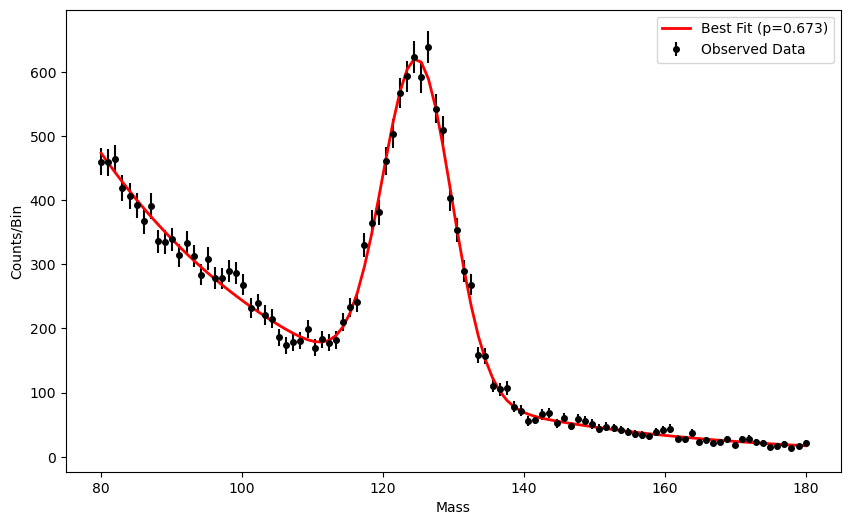

Fit complete with p-value: 0.673
Correlation matrix:
[[ 1.          0.16180854 -0.08453533  0.36080076 -0.26159511]
 [ 0.16180854  1.          0.05054627  0.1317794  -0.94918486]
 [-0.08453533  0.05054627  1.         -0.1189906  -0.02935232]
 [ 0.36080076  0.1317794  -0.1189906   1.         -0.2175895 ]
 [-0.26159511 -0.94918486 -0.02935232 -0.2175895   1.        ]]


In [35]:
# Provide initial guesses for the fitter. Using the "true" values is a good start.
initial_guesses = [N_sig_true, N_bkg_true, mu_true, sigma_true, tau_true]

# 1. Perform the fit saving the results as `popt` and `pcov`. 
# Make sure to pass the data errors using the `sigma` argument so it performs a proper chi-squared fit and use `absolute_sigma=True`.
popt = pcov = None

def scaled_total(x, *params):
    return model_total(x, *params) * bin_width

popt, pcov = curve_fit(scaled_total, x_data, y_observed, p0=initial_guesses, sigma=y_errors, absolute_sigma=True)

# 2. Write the formula to calculate the chi-squared value `chi2_value`.
#    Formula: chi2 is the sum of [ (observed - expected)^2 / error^2 ]

fitted_y = scaled_total(x_data, *popt)
chi2_value = np.sum(((y_observed - fitted_y)**2)/((y_errors)**2))

print(chi2_value)


# 3. Calculate the degrees of freedom, `dof` and the p-value `p_value`.
#    Formula: dof is the number of data points - number of fitted parameters.
#    Formula: p_value is (1 - chi2.cdf(chi2_value, dof))
dof = len(x_data) - len(popt)
p_value = 1 - chi2.cdf(chi2_value, dof)


# 4. Plot the fit curve on top of the data points with error bars.

plt.figure(figsize=(10, 6))
plt.errorbar(x_data, y_observed, yerr=y_errors, fmt='ko', label='Observed Data', markersize=4)
plt.plot(x_data, fitted_y, 'r-', linewidth=2, label=f'Best Fit (p={p_value:.3f})')
plt.xlabel('Mass')
plt.ylabel('Counts/Bin')
plt.legend()
plt.show()

# 5. Print the covariance matrix for the fitted parameters.
perr = np.sqrt(np.diag(pcov))
correlation_matrix = pcov / np.outer(perr, perr)

print(f"Fit complete with p-value: {p_value:.3f}")
print(f"Correlation matrix:\n{correlation_matrix}")

The most important step is to check if our fitting procedure is biased. We will do this by generating and fitting hundreds of "toy" experiments.

In [36]:
# 1. Use the `multivariate_normal.rvs` method to sample the parameter values using the fitted parameters and their covariance.
# For each toy, fit the model and calculate the pull for each fitted parameter.
# Formula: (Fitted Value - True Value) / Fitted Error

num_toys = 1000
toy_truth_dist = multivariate_normal(mean=popt, cov=pcov, allow_singular=True)

pulls = {'N_bkg': [], 'N_sig': [], 'tau': [], 'mu': [], 'sigma': []}
param_keys = list(pulls.keys())

while len(pulls['N_bkg']) < num_toys:

    # Set up the toy data
    toy_params = toy_truth_dist.rvs()
    toy_expected = scaled_total(x_data, *toy_params)
    toy_observed = np.random.poisson(toy_expected)
    # Errors
    toy_errors = np.sqrt(toy_observed)
    toy_errors[toy_errors == 0] = 1.0

    try:
        # Attempt to fit the data with our original popt params
        toy_popt, toy_pcov = curve_fit(scaled_total, x_data, toy_observed, p0=popt, sigma=toy_errors, absolute_sigma=True)
        toy_perr = np.sqrt(np.diag(toy_pcov)) # Find uncertainties

        pull_vals = (toy_popt - toy_params) / toy_perr

        #Store
        pulls['N_sig'].append(pull_vals[0])
        pulls['N_bkg'].append(pull_vals[1])
        pulls['mu'].append(pull_vals[2])
        pulls['sigma'].append(pull_vals[3])
        pulls['tau'].append(pull_vals[4])

    except Exception:
        # Skip and try again until done
        continue

print(f"{len(pulls['N_bkg'])} toy experiments successfully fitted.")

1000 toy experiments successfully fitted.


Determine the mean and width of the pull distributions and evaluate the fit bias

TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

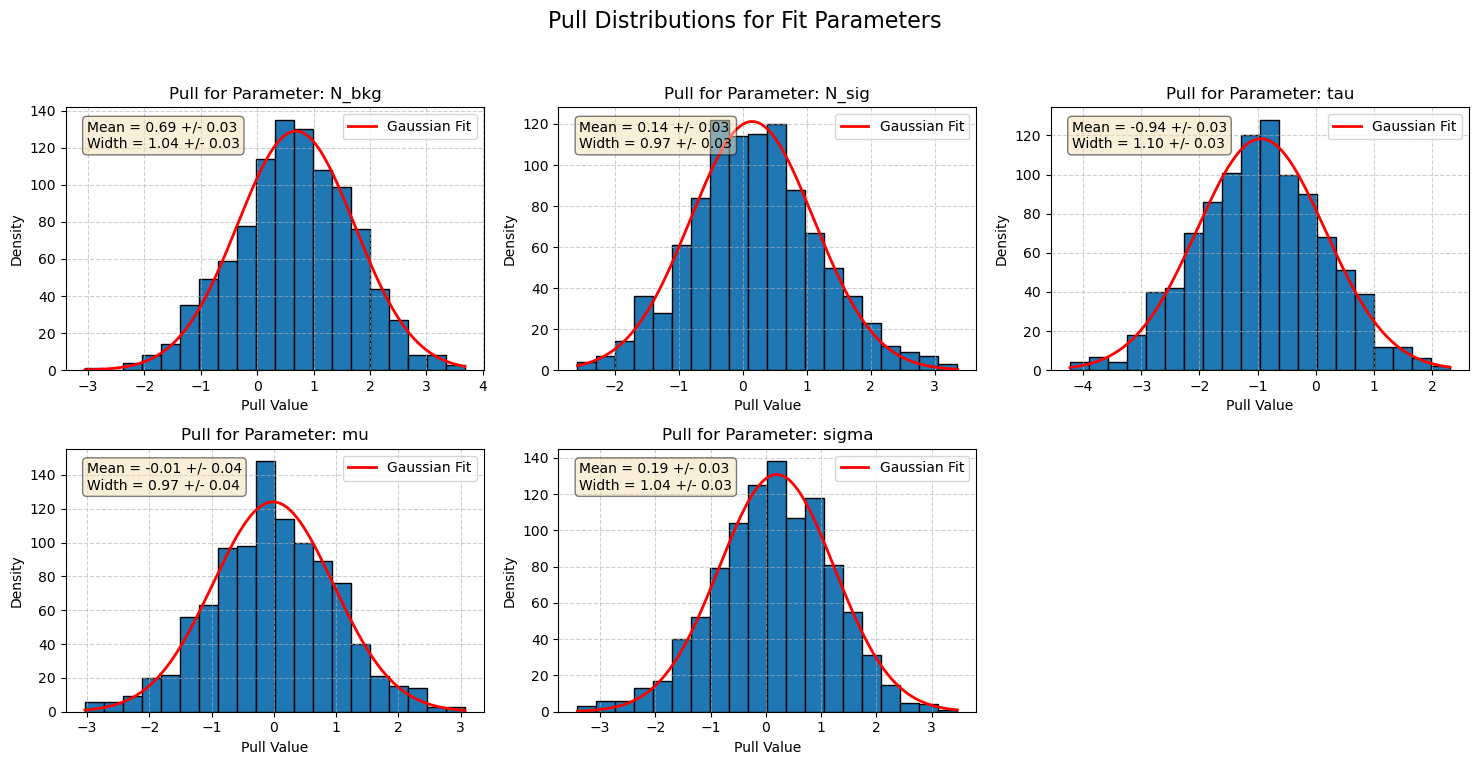

In [38]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
# Create histograms for each parameter's pull distribution
for i, key in enumerate(param_keys):
    ax = axes[i]
    p = pulls[key]

    # Create the histogram
    counts, bin_edges = np.histogram(p, bins=20)
    ax.bar(
    bin_edges[:-1],          # Left edge of each bar
    counts,                  # Height of each bar
    width=np.diff(bin_edges),# Width of each bar
    align='edge',            # Align bars by their left edge
    edgecolor='black'
)
    
    # 1. Fit a Gaussian to the binned pull distribution above with `pars` and `cov` and plot it on top of the histogram.
    
    # Find bin centres
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Gaussian
    def gaussian_fit_func(x, A, mu, sigma):
        return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

    init = [np.max(counts), 0.0, 1.0]
    pars, cov = curve_fit(gaussian_fit_func, bin_centers, counts, p0=init)

    # Plot as per the stuff below
    x_plot = np.linspace(bin_edges[0], bin_edges[-1], 500)
    ax.plot(x_plot, gaussian_fit_func(x_plot, *pars), 'r-', linewidth=2, label='Gaussian Fit')
    ax.set_title(f'Pull for Parameter: {key}')
    ax.set_xlabel('Pull Value')
    ax.set_ylabel('Density')
    ax.grid(True, linestyle='--', alpha=0.6)
    # Display the results of the Gaussian fit on the plot
    text_str = f'Mean = {pars[1]:.2f} +/- {np.sqrt(cov[1,1]):.2f}\nWidth = {pars[2]:.2f} +/- {np.sqrt(cov[2,2]):.2f}'
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend()

fig2.suptitle('Pull Distributions for Fit Parameters', fontsize=16)
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
axes[5].axis('off')
plt.savefig('pulls')
plt.show()